k1: sigx,sigy= 32.0 3.99 5.38
k1: sigx,sigy= 32.0 3.97 5.43
k1: sigx,sigy= 32.0 3.91 5.42
k1: sigx,sigy= 32.0 3.95 5.42
k1: sigx,sigy= 32.0 3.97 5.41
k1: sigx,sigy= 32.0 4.01 5.38
k1: sigx,sigy= 32.0 3.96 5.46
k1: sigx,sigy= 32.0 3.94 5.43
k1: sigx,sigy= 32.0 3.99 5.41
k1: sigx,sigy= 32.0 3.98 5.4
k1: sigx,sigy= 32.63157894736842 3.5 5.51
k1: sigx,sigy= 32.63157894736842 3.48 5.52
k1: sigx,sigy= 32.63157894736842 3.5 5.45
k1: sigx,sigy= 32.63157894736842 3.53 5.48
k1: sigx,sigy= 32.63157894736842 3.5 5.51
k1: sigx,sigy= 32.63157894736842 3.51 5.51
k1: sigx,sigy= 32.63157894736842 3.51 5.45
k1: sigx,sigy= 32.63157894736842 3.51 5.47
k1: sigx,sigy= 32.63157894736842 3.47 5.5
k1: sigx,sigy= 32.63157894736842 3.5 5.48
k1: sigx,sigy= 33.26315789473684 3.1 5.54
k1: sigx,sigy= 33.26315789473684 3.05 5.64
k1: sigx,sigy= 33.26315789473684 3.06 5.61
k1: sigx,sigy= 33.26315789473684 3.1 5.55
k1: sigx,sigy= 33.26315789473684 3.09 5.58
k1: sigx,sigy= 33.26315789473684 3.07 5.61
k1: sigx,sigy= 33.26

k1: sigx,sigy= 44.0 4.48 5.72
k1: sigx,sigy= 44.0 4.51 5.7
k1: sigx,sigy= 44.0 4.54 5.77
k1: sigx,sigy= 44.0 4.45 5.79
program finished.


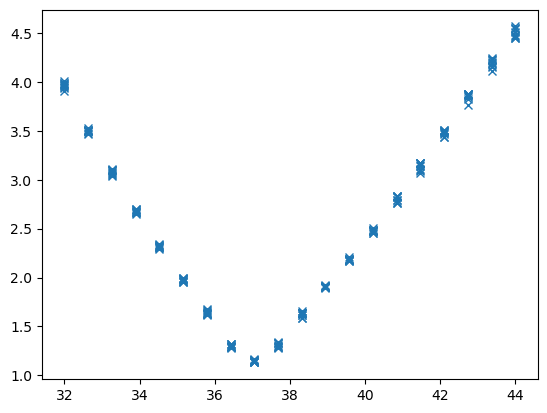

In [4]:
import epics as ep
import numpy as np
import time

import matplotlib.pyplot as plt

quad_pv = "IRFEL:AP:QUAD:MQ2:K1:ao"

sigx_pv = "IRFEL:BD:flag4:sigx" 
sigy_pv = "IRFEL:BD:flag4:sigy" 

npt = 20
samples = 10
k1l = np.linspace(32,44,npt)

sigxl = []
sigyl = []

kkl = []
for k1 in k1l:
    
    for j in range(samples):
        # set quad
        ep.caput(quad_pv,k1)

        time.sleep(5)

        #get sigx,sigy
        sigx = ep.caget(sigx_pv)
        sigy = ep.caget(sigy_pv)

        print("k1: sigx,sigy=",round(k1,2),sigx,sigy)
        
        kkl.append(k1)
        sigxl.append(sigx)
        sigyl.append(sigy)
    
print("program finished.")


In [20]:
data=[kkl,sigxl,sigyl]

np.savetxt("0329_k1_sigx_sigy.txt",data)


Text(0, 0.5, '$sigx^2$')

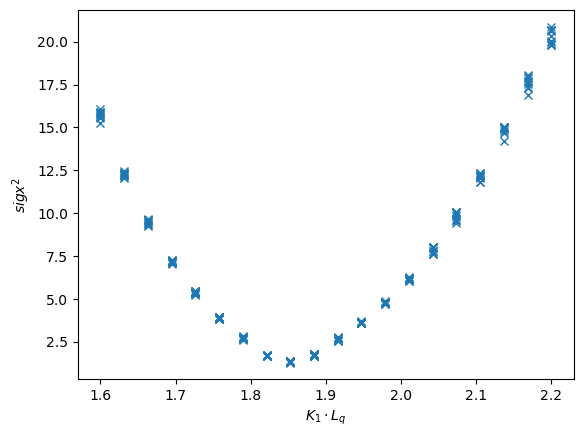

In [29]:
K =np.array(kkl)*0.05
sig11 = np.square(sigxl)

plt.figure
plt.plot(K,sig11,"x")
plt.xlabel("$K_1\cdot L_q$")
plt.ylabel("$sigx^2$")

Text(0, 0.5, '$sigy^2$')

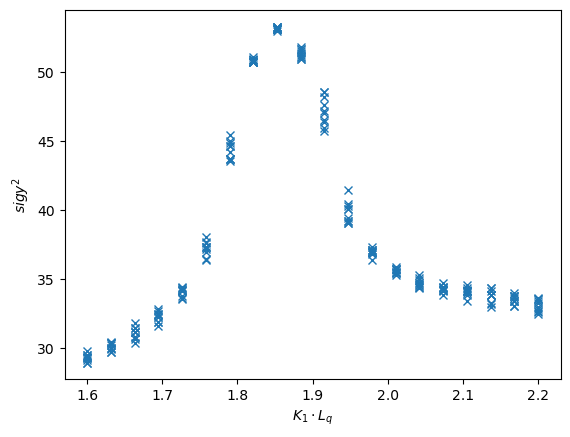

In [30]:
K =np.array(kkl)*0.05
sig11 = np.square(sigyl)

plt.figure
plt.plot(K,sig11,"x")
plt.xlabel("$K_1\cdot L_q$")
plt.ylabel("$sigy^2$")